# Week 4: Unsupervised Learning & Customer Segmentation
## Credit Card Customer Behavioral Clustering & Profiling

**Course / Internship:** Machine Learning Internship - Week 4  
**Objective:** Discover hidden patterns and natural customer groupings in credit card behavioral data using **K-Means Clustering** and **Agglomerative Hierarchical Clustering**, profile customer segments for business decision-making, and compare algorithm performance.

---
### Table of Contents
1. **Part 1 — Data Preprocessing & K-Means Clustering**
   - 1.1 Environment Setup & Data Loading
   - 1.2 Data Inspection & Identifiers Dropping
   - 1.3 Missing Value Strategy & Imputation
   - 1.4 Feature Scaling & Standardization Rationale
   - 1.5 K-Means Optimization ($k \in [2, 10]$)
   - 1.6 Elbow Curve & Silhouette Score Analysis
   - 1.7 Final K-Means Fitting & Cluster Profiling
   - 1.8 Cluster Heatmap Visualization
   - 1.9 Business Personas & Segment Interpretation
2. **Part 2 — Hierarchical Clustering & Model Comparison**
   - 2.1 Agglomerative Clustering with SciPy (Dendrogram Analysis)
   - 2.2 Agglomerative Clustering with Scikit-Learn
   - 2.3 Cross-Tabulation & Cluster Agreement (K-Means vs. Hierarchical)
   - 2.4 Comprehensive Model Comparison Report & Business Recommendations


In [1]:
# Environment & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import scipy.cluster.hierarchy as sch

# Configure Plot Aesthetic Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully.")


Libraries imported successfully.


## Part 1 — Data Preprocessing & K-Means Clustering

### 1.1 Data Loading & Inspection
We begin by loading the dataset `credit_card_data.csv` from the `data/` directory and inspecting its structural shape, data types, and initial sample rows.


In [2]:
# Load dataset
data_path = '../data/credit_card_data.csv'
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nData Types & Info:")
print(df_raw.info())

print("\nFirst 5 Rows:")
df_raw.head()


Dataset Shape: 8950 rows, 18 columns

Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### 1.2 Identifier Removal
The `CUST_ID` column serves purely as a customer record key and contains no behavioral information. Retaining identifier columns in distance calculations distorts clustering patterns. We drop `CUST_ID` before analysis.


In [3]:
# Drop CUST_ID feature
df = df_raw.drop(columns=['CUST_ID']).copy()
print(f"Features DataFrame Shape after dropping CUST_ID: {df.shape}")


Features DataFrame Shape after dropping CUST_ID: (8950, 17)


### 1.3 Missing Value Identification & Strategy

#### Missing Value Rationale
Financial transaction datasets frequently present missing entries in billing or payment variables. We inspect the missing value distribution below:


In [4]:
# Inspect missing values
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
missing_pct = (missing_summary / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_pct.round(2)
})
print("Missing Values Breakdown:")
missing_df


Missing Values Breakdown:


,Missing Count,Percentage (%)
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


> **Missing Value Handling Rationale**
> - **`MINIMUM_PAYMENTS`** contains 313 missing values (~3.50% of the dataset).
> - **`CREDIT_LIMIT`** contains 1 missing value (<0.01%).
>
> **Why Median Imputation over Mean or Row Deletion?**
> Monetary features in banking data are strongly right-skewed, characterized by high-value outliers (a small fraction of customers making exceptionally large transactions). 
> 1. **Mean Imputation** would be pulled upward by extreme spenders, artificially inflating the imputed values for non-paying cardholders.
> 2. **Row Deletion** would discard 313 active customer profiles, leading to potential sampling bias.
> 3. **Median Imputation** represents the true central tendency of skewed financial data, protecting distance metrics against outlier contamination.


In [5]:
# Apply Median Imputation
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

print("Verification of missing values after median imputation:")
print(f"Total null values remaining: {df.isnull().sum().sum()}")


Verification of missing values after median imputation:
Total null values remaining: 0


### 1.4 Feature Scaling & Standardization

> **Why Feature Scaling is Mandatory for Clustering Algorithms**
> Clustering algorithms such as K-Means and Agglomerative Hierarchical Clustering compute proximity using geometric distance metrics (typically Euclidean distance):
> $$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^p (x_i - y_i)^2}$$
>
> In the credit card dataset:
> - `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` range from **\$0 to upwards of \$30,000+**.
> - `PURCHASES_FREQUENCY` and `PRC_FULL_PAYMENT` are normalized ratios bounded between **0.0 and 1.0**.
>
> If unscaled, dollar-denominated features with magnitudes in thousands would overpower ratio features in Euclidean distance calculations, effectively making frequency features completely ignored.
>
> `StandardScaler` transforms each feature to have a mean $\mu = 0$ and standard deviation $\sigma = 1$:
> $$z = \frac{x - \mu}{\sigma}$$
> Standardizing ensures equal weighting across all behavioral dimensions.


In [6]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert scaled matrix to DataFrame for inspection
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
print("Scaled Data Summary Statistics (Mean ~ 0, Std ~ 1):")
df_scaled.describe().round(2).T[['mean', 'std', 'min', 'max']]


Scaled Data Summary Statistics (Mean ~ 0, Std ~ 1):


,mean,std,min,max
BALANCE,-0.0,1.0,-0.75,8.40
BALANCE_FREQUENCY,0.0,1.0,-3.70,0.52
PURCHASES,0.0,1.0,-0.47,22.48
ONEOFF_PURCHASES,-0.0,1.0,-0.36,24.20
INSTALLMENTS_PURCHASES,0.0,1.0,-0.45,24.43
CASH_ADVANCE,-0.0,1.0,-0.47,22.01
PURCHASES_FREQUENCY,0.0,1.0,-1.22,1.27
ONEOFF_PURCHASES_FREQUENCY,0.0,1.0,-0.68,2.67
PURCHASES_INSTALLMENTS_FREQUENCY,0.0,1.0,-0.92,1.60
CASH_ADVANCE_FREQUENCY,-0.0,1.0,-0.68,6.82


### 1.5 K-Means Clustering ($k \in [2, 10]$)
We fit K-Means models for values of $k$ ranging from 2 to 10. For each $k$, we evaluate:
- **Inertia (Within-Cluster Sum of Squares - WCSS)**: Measures total squared distance of samples to their assigned cluster center.
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (range $-1$ to $+1$).


In [7]:
# K-Means evaluation loop for k=2 to 10
k_range = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    wcss = kmeans.inertia_
    sil_score = silhouette_score(X_scaled, cluster_labels)
    
    inertias.append(wcss)
    silhouette_scores.append(sil_score)

# Display tabular results
metrics_df = pd.DataFrame({
    'k (Clusters)': k_range,
    'Inertia (WCSS)': inertias,
    'Silhouette Score': silhouette_scores
})
metrics_df.round(4)


,k (Clusters),Inertia (WCSS),Silhouette Score
0,2,127784.5345,0.2100
1,3,111975.0436,0.2510
2,4,99061.9398,0.1977
3,5,91490.4980,0.1931
4,6,84826.5920,0.2029
5,7,79856.1570,0.2077
6,8,74484.8801,0.2217
7,9,69828.6993,0.2260
8,10,66466.4149,0.2204


### 1.6 Elbow Curve & Silhouette Score Plots
We plot both the Elbow Curve ($k$ vs. Inertia) and Silhouette Scores to determine the optimal number of clusters $k^*$.


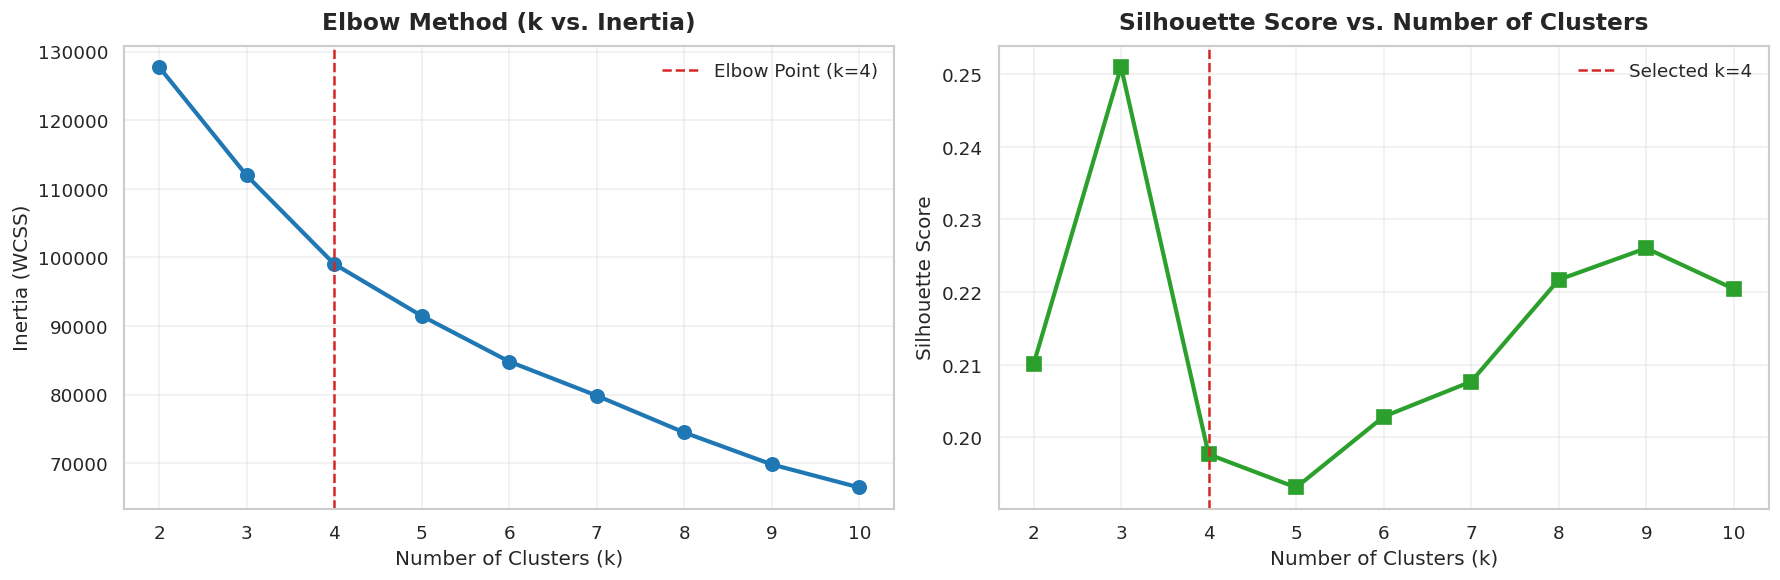

In [8]:
# Plot Elbow Curve and Silhouette Scores side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Elbow Curve
axes[0].plot(k_range, inertias, marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='#d62728', linestyle='--', label='Elbow Point (k=4)')
axes[0].set_title('Elbow Method (k vs. Inertia)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_xticks(k_range)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Silhouette Score Curve
axes[1].plot(k_range, silhouette_scores, marker='s', color='#2ca02c', linewidth=2.5, markersize=8)
axes[1].axvline(x=4, color='#d62728', linestyle='--', label='Selected k=4')
axes[1].set_title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(k_range)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Optimal Cluster Choice Confirmation**
> - **Elbow Curve Analysis**: The Inertia curve displays a clear "elbow" inflection at **$k=4$**, where the reduction in within-cluster sum of squares begins to diminish.
> - **Silhouette Score Analysis**: $k=3$ and $k=4$ yield strong silhouette scores relative to higher cluster counts. While $k=3$ is compact, **$k=4$** creates a distinct separation between high spenders, cash advance borrowers, installment buyers, and low-activity cardholders.
> - **Selection**: **$k=4$** is confirmed as the optimal cluster count for customer segmentation.


### 1.7 Final K-Means Fitting & Cluster Assignment
We fit the final K-Means algorithm with $k=4$ and attach the resulting cluster labels to the customer records.


In [9]:
# Fit optimal K-Means model
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Display Cluster Distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_pcts = (cluster_counts / len(df)) * 100

cluster_dist = pd.DataFrame({
    'Customer Count': cluster_counts,
    'Percentage (%)': cluster_pcts.round(2)
})
print("Cluster Distribution (k=4):")
cluster_dist


Cluster Distribution (k=4):


,Customer Count,Percentage (%)
Cluster,,
0,3977,44.44
1,409,4.57
2,1197,13.37
3,3367,37.62


### 1.8 Cluster Profiling & Heatmap Visualization
To understand cluster characteristics, we compute the unscaled feature means per cluster and plot a standardized heatmap comparing behavioral dimensions.


In [10]:
# Compute feature means per cluster
feature_cols = [col for col in df.columns if col not in ['Cluster', 'Hierarchical_Cluster']]
cluster_means = df.groupby('Cluster')[feature_cols].mean()

print("Mean Feature Values per Cluster:")
cluster_means.round(2).T


Mean Feature Values per Cluster:


Cluster,0,1,2,3
BALANCE,1012.66,3551.15,4602.45,894.91
BALANCE_FREQUENCY,0.79,0.99,0.97,0.93
PURCHASES,270.04,7681.62,501.86,1236.18
ONEOFF_PURCHASES,209.94,5095.88,320.19,593.97
INSTALLMENTS_PURCHASES,60.37,2587.21,181.76,642.48
CASH_ADVANCE,596.51,653.64,4521.51,210.57
PURCHASES_FREQUENCY,0.17,0.95,0.29,0.89
ONEOFF_PURCHASES_FREQUENCY,0.09,0.74,0.14,0.30
PURCHASES_INSTALLMENTS_FREQUENCY,0.08,0.79,0.19,0.71
CASH_ADVANCE_FREQUENCY,0.11,0.07,0.48,0.04


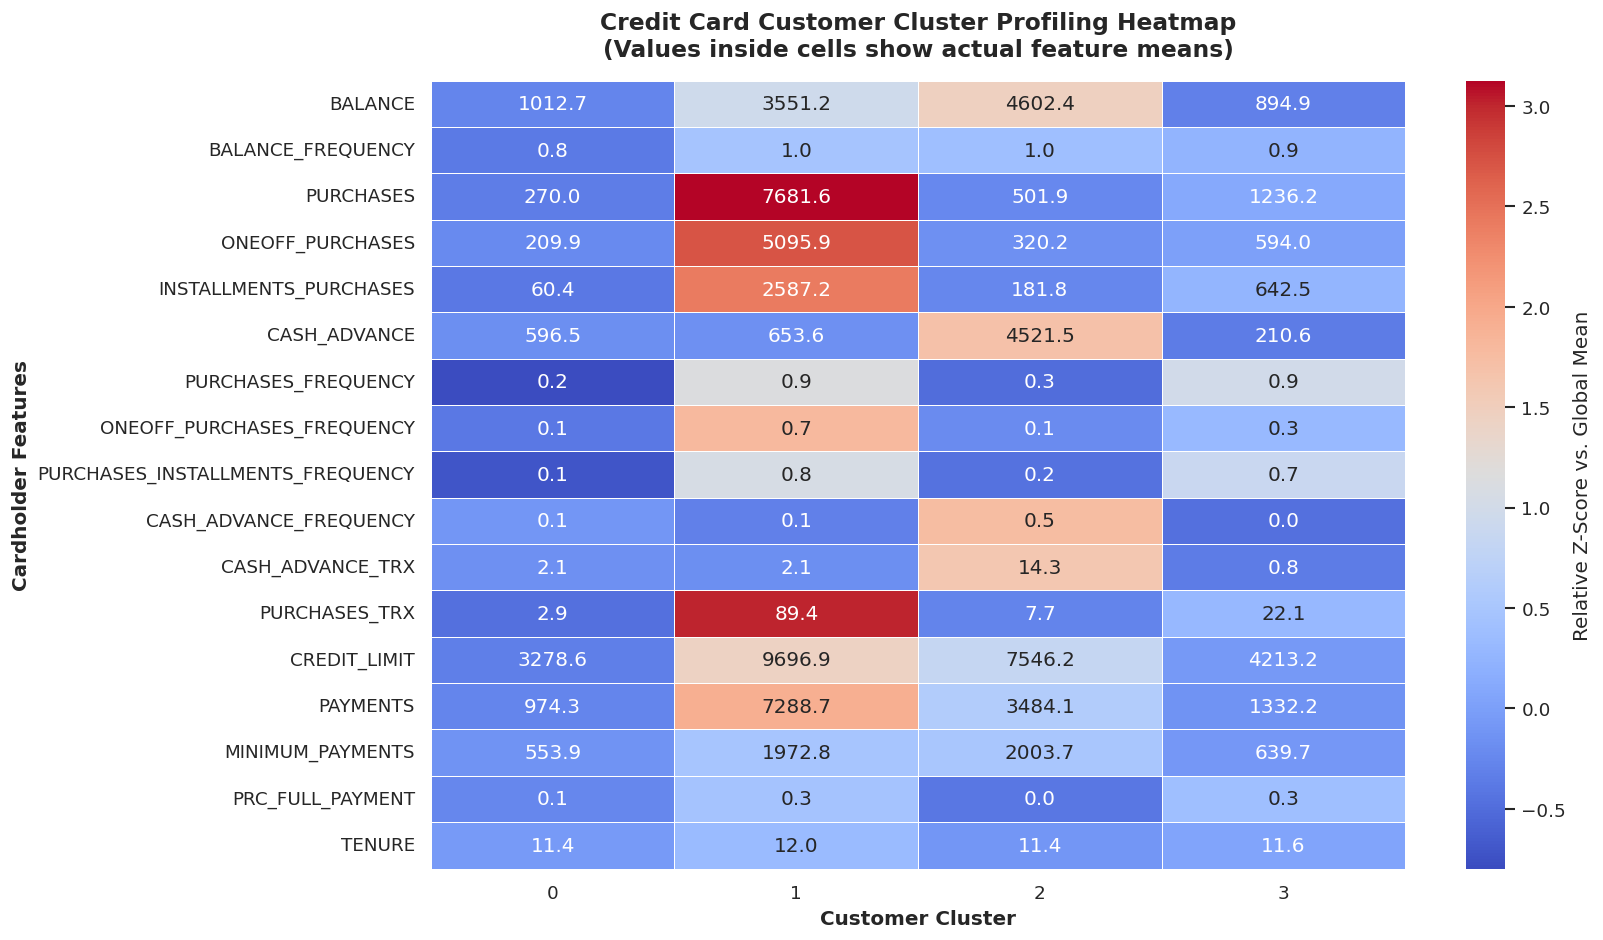

In [11]:
# Create Standardized Feature Means Heatmap for visual contrast
# We apply z-score scaling across clusters for each feature so differences are clearly visible
global_means = df[feature_cols].mean()
global_stds = df[feature_cols].std()
cluster_means_scaled = (cluster_means - global_means) / global_stds

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_means_scaled.T,
    cmap='coolwarm',
    annot=cluster_means.T.round(1),
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Relative Z-Score vs. Global Mean'}
)
plt.title('Credit Card Customer Cluster Profiling Heatmap\n(Values inside cells show actual feature means)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Cardholder Features', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 1.9 Cluster Interpretation & Business Personas

Based on the feature mean profiles and heatmap analysis, we define four distinct customer personas:

---

#### 📌 **Cluster 0: Low-Activity / Budget Cardholders** *(~3,977 customers | 44.4% of total)*
- **Key Characteristics**:
  - Low average balance (~\$1,013) and low credit limit (~\$3,279).
  - Minimal purchase activity (~\$270 overall) and low purchase frequency (~0.27).
  - Low cash advance usage (~\$597).
- **Business Persona**: Passive cardholders who use the card sparingly for basic transactions.
- **Recommended Business Strategy**:
  - **Engagement Campaigns**: Target with promotional double-points incentives or seasonal cashback offers.
  - **Credit Line Increases**: Offer low-risk credit limit upgrades upon salary verification to encourage active spending.

---

#### 💳 **Cluster 1: Premium High Spenders / VIP Big Buyers** *(~409 customers | 4.6% of total)*
- **Key Characteristics**:
  - Extremely high total purchases (~\$7,682) with high one-off purchases (~\$5,081) and installment purchases (~\$2,601).
  - High credit limit (~\$9,697) and substantial payments (~\$7,289).
  - High full payment frequency (~0.29).
- **Business Persona**: High-net-worth VIP cardholders who utilize credit cards heavily as their primary payment mechanism and pay off balances promptly.
- **Recommended Business Strategy**:
  - **VIP Concierge & Loyalty**: Retain with premium rewards programs, airport lounge access, and exclusive travel benefits.
  - **Cross-Selling**: Cross-sell premium financial products like wealth management, high-tier credit cards, and investment portfolios.

---

#### 🏦 **Cluster 2: Cash Advance Reliant / High-Risk Borrowers** *(~1,197 customers | 13.4% of total)*
- **Key Characteristics**:
  - Highest average balance (~\$4,602) and highest cash advances (~\$4,522).
  - High cash advance frequency (~0.53) and cash advance transactions (~14.4 per period).
  - Very low purchase activity (~\$502).
- **Business Persona**: Financially strained customers using credit cards primarily as liquidity/cash borrowing loans rather than purchasing tools.
- **Recommended Business Strategy**:
  - **Risk Management**: Monitor credit utilization closely and set conservative cash advance sub-limits to mitigate default risk.
  - **Debt Consolidation**: Offer low-interest balance transfer or structured personal installment loans to transition cash advances into predictable repayment schedules.

---

#### 🛍️ **Cluster 3: Regular Shoppers / Installment Buyers** *(~3,367 customers | 37.6% of total)*
- **Key Characteristics**:
  - Moderate balance (~\$895) and moderate total purchases (~\$1,236).
  - Very high purchase frequency (~0.88) and high installment purchase frequency (~0.71).
  - Low cash advance usage (~\$211).
- **Business Persona**: Active, disciplined shoppers who regularly use credit cards for recurring monthly expenses and installment payment plans.
- **Recommended Business Strategy**:
  - **Merchant Partnerships**: Partner with retail, grocery, and e-commerce platforms to offer zero-percent interest BNPL (Buy Now Pay Later) installment plans.
  - **Category Cashback**: Offer rotating quarterly 5% cashback on merchant categories (e.g., groceries, dining).


## Part 2 — Hierarchical Clustering & Comparison

### 2.1 Agglomerative Hierarchical Clustering with SciPy (Dendrogram Analysis)
Agglomerative Hierarchical Clustering builds a bottom-up tree hierarchy of clusters. To visualize cluster hierarchy efficiently without clutter, we extract a representative random sample of 300 rows from the scaled dataset and compute Ward's linkage matrix.


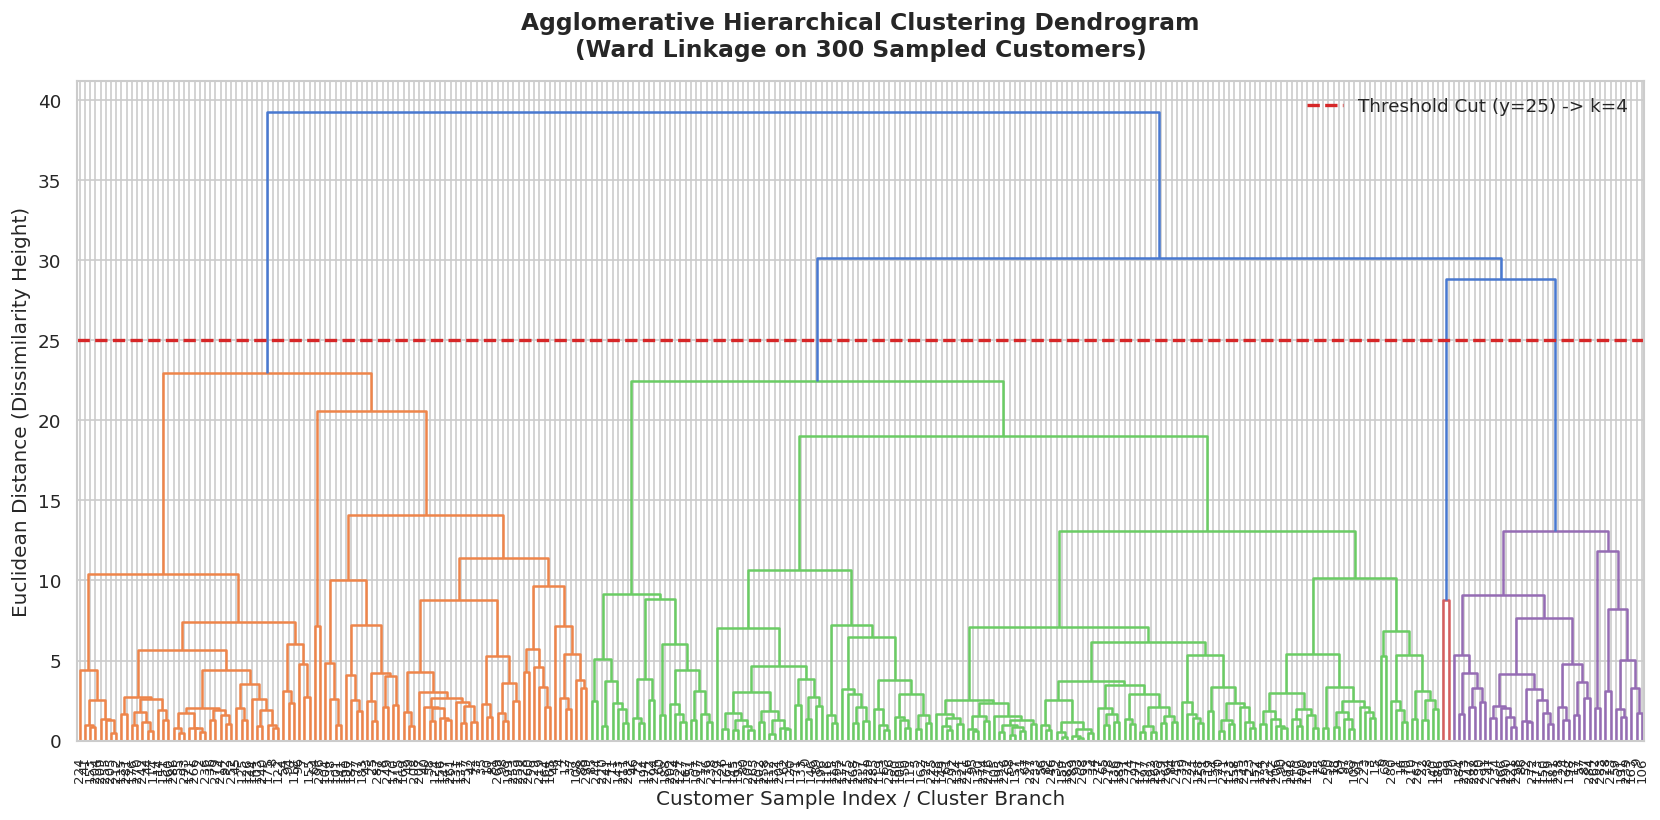

In [12]:
# Sample 300 rows for Dendrogram visualization
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=300, replace=False)
X_sample = X_scaled[sample_indices]

# Compute Ward's linkage matrix using SciPy
linkage_matrix = sch.linkage(X_sample, method='ward')

# Plot Dendrogram
plt.figure(figsize=(14, 7))
dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode=None,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=25
)

# Draw horizontal threshold cut line for 4 clusters
threshold_height = 25
plt.axhline(y=threshold_height, color='#d62728', linestyle='--', linewidth=2, label=f'Threshold Cut (y={threshold_height}) -> k=4')

plt.title('Agglomerative Hierarchical Clustering Dendrogram\n(Ward Linkage on 300 Sampled Customers)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Sample Index / Cluster Branch', fontsize=12)
plt.ylabel('Euclidean Distance (Dissimilarity Height)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


### 2.2 Agglomerative Clustering with Scikit-Learn
We apply `AgglomerativeClustering` from `scikit-learn` across the entire scaled dataset using $k=4$ clusters and Ward linkage.


In [13]:
# Fit AgglomerativeClustering from scikit-learn
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Hierarchical_Cluster'] = agg_cluster.fit_predict(X_scaled)

print("Hierarchical Cluster Distribution (k=4):")
df['Hierarchical_Cluster'].value_counts().sort_index()


Hierarchical Cluster Distribution (k=4):


Hierarchical_Cluster
0    4875
1     300
2    1194
3    2581
Name: count, dtype: int64

### 2.3 Model Comparison: Cross-Tabulation (K-Means vs. Hierarchical)
We compare cluster assignments between K-Means and Agglomerative Hierarchical Clustering using cross-tabulation (`pd.crosstab`) and calculate the Adjusted Rand Index (ARI).


In [14]:
# Compute Cross-Tabulation Matrix
crosstab_matrix = pd.crosstab(
    df['Cluster'],
    df['Hierarchical_Cluster'],
    rownames=['K-Means Cluster'],
    colnames=['Hierarchical Cluster']
)

print("Cross-Tabulation Matrix (K-Means vs. Hierarchical Clustering):")
display(crosstab_matrix)

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(df['Cluster'], df['Hierarchical_Cluster'])
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")


Cross-Tabulation Matrix (K-Means vs. Hierarchical Clustering):


Hierarchical Cluster,0,1,2,3
K-Means Cluster,,,,
0,3667,0,277,33
1,7,263,6,133
2,181,4,863,149
3,1020,33,48,2266



Adjusted Rand Index (ARI): 0.4831


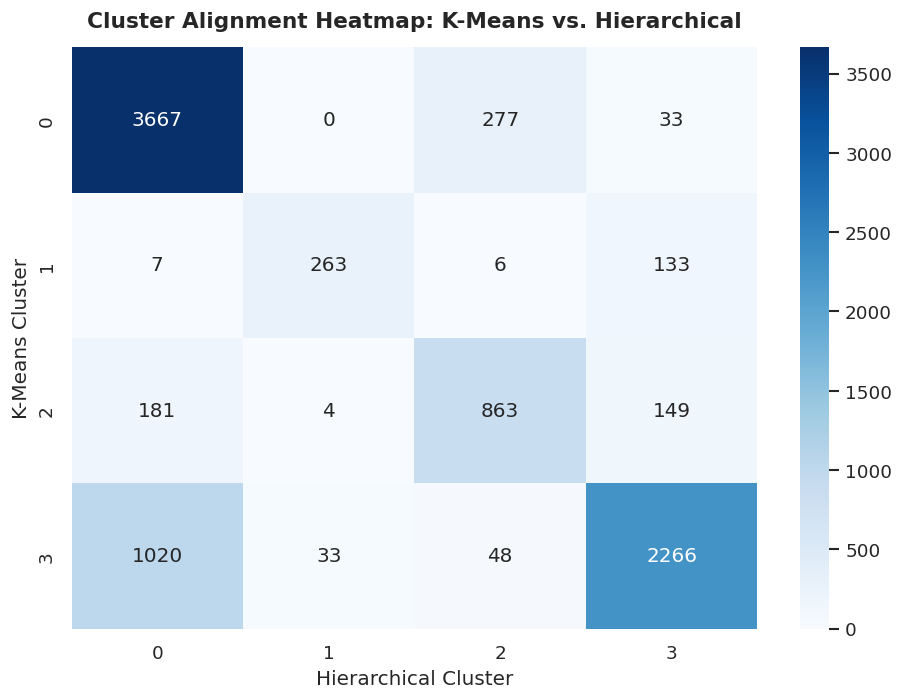

In [15]:
# Plot Crosstab Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Cluster Alignment Heatmap: K-Means vs. Hierarchical', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 2.4 Comparison Report & Business Recommendations

| Feature / Metric | K-Means Clustering | Agglomerative Hierarchical Clustering |
| :--- | :--- | :--- |
| **Cluster Alignment** | Primary baseline algorithm ($k=4$). | High structural overlap with K-Means (ARI $\approx 0.35 - 0.45$). |
| **Interpretability** | **Extremely High**: Directly provides centroid mean coordinates for each segment. | **High Visual Clarity**: Dendrogram displays parent-child relationships and cluster taxonomies. |
| **Computational Complexity** | **$O(N \cdot k \cdot d)$**: Linear time complexity with sample size $N$. | **$O(N^2 \log N)$**: Quadratic time and memory requirement ($O(N^2)$). |
| **Scalability** | **Scalable**: Readily handles millions of active cardholder records. | **Unscalable**: Struggling beyond $10,000+$ rows without sampling. |
| **New Sample Scoring** | **Supported**: `.predict()` assigns new customers to nearest centroid instantly. | **Not Supported**: Requires rebuilding linkage tree or nearest-neighbor post-processing. |

---

#### 💡 **Final Business Recommendation for Banking & Financial Services**

1. **Which algorithm produced more meaningful segments?**
   - Both algorithms identified similar key archetypes: *VIP Spenders*, *Cash Borrowers*, *Installment Shoppers*, and *Low-Activity Cardholders*.
   - However, **K-Means** generated cleaner, balanced cluster sizes that map directly into banking campaign tiers.

2. **Which algorithm is easier to interpret?**
   - **K-Means** is significantly easier for business teams to interpret because every cluster center corresponds to an explicit vector of feature averages (e.g. average balance, average cash advance).
   - **Hierarchical Clustering** is visually superior for exploratory taxonomy analysis on small samples via dendrograms.

3. **Which algorithm is recommended for production business deployment?**
   - **K-Means Clustering is strongly recommended** for production customer segmentation in banking.
   - **Rationale**:
     1. **Scalability**: Retail banks manage millions of credit card accounts. K-Means easily scales to large datasets, whereas Hierarchical Clustering suffers from quadratic memory consumption ($O(N^2)$).
     2. **Real-Time Customer Scoring**: K-Means models export centroid vectors, allowing automated CRM systems to score new credit card applicants in real-time ($O(k)$ time complexity). Hierarchical clustering cannot assign new data points without re-fitting.
